<a href="https://colab.research.google.com/github/J-PerezVi/Proyecto-Jhonatan-Perez/blob/main/JhonatanPerez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
from google.colab import files
uploaded = files.upload()



Saving Iris.csv to Iris (1).csv


1. Importar y DatafRAME

In [21]:
import pandas as pd

df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [22]:
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

print(df.shape)
print(df.head())

(150, 5)
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa


2. Análisis exploratorio

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count     150.000000    150.000000     150.000000    150.000000
mean        5.843333      3.054000       3.758667      1.198667
std         0.828066      0.433594       1.764420      0.763161
min         4.300000      2.000000       1.000000      0.100000
25%         5.100000      2.800000       1.600000      0.300000
50%         5.800000      3.000000       4.350000      1.300000
75%         6.400000      3.300000       5.100000      1.800000
max         7.90000

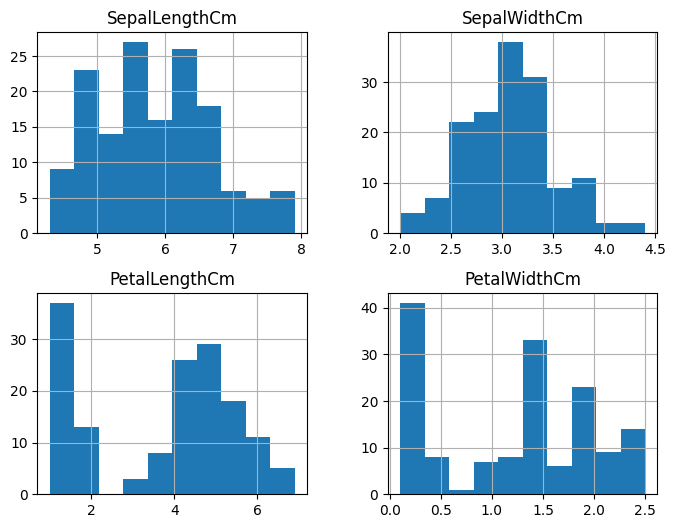

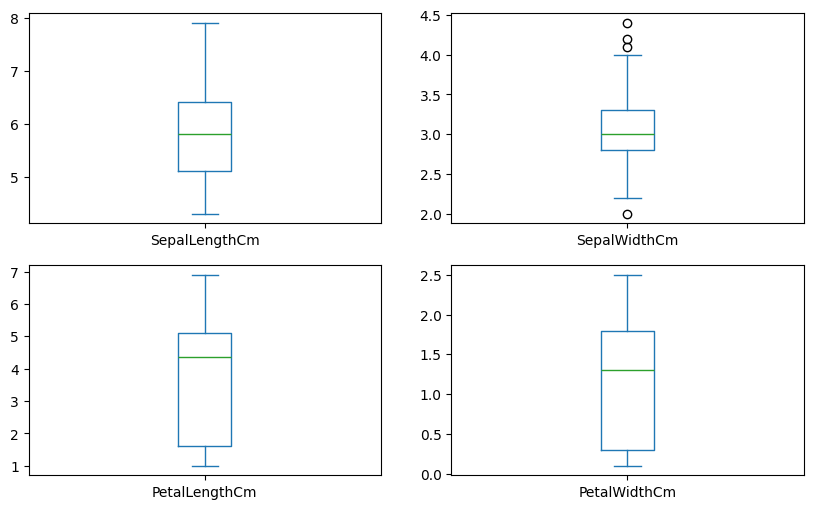

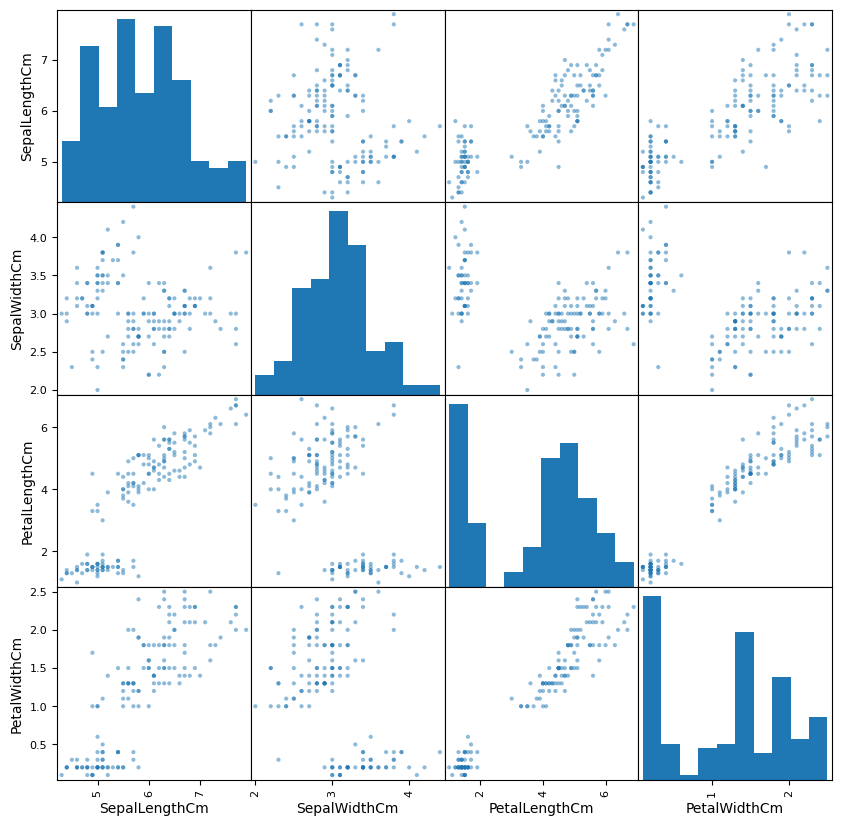

In [23]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

# Resumen de datos
print(df.info())
print(df.describe())
print("\nDistribución de Species:\n", df['Species'].value_counts())

# Histogramas
df.hist(figsize=(8,6))
plt.show()

# Boxplots
df.plot(kind='box', subplots=True, layout=(2,2), figsize=(10,6))
plt.show()

# Matriz de dispersión
scatter_matrix(df.iloc[:,:-1], figsize=(10,10), diagonal='hist')
plt.show()


3. Modelo de clasificación con KNN (k=8,9,10)

In [24]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Variables explicativas y target
X = df.drop(columns=['Species'])
y = df['Species']

# Codificar etiquetas (Species)
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir en entrenamiento (80%) y test (20%)
X_train, X_test, y_train, y_test = train_test_split(
X_scaled, y_enc, test_size=0.2, random_state=42, stratify=y_enc)



4. Evaluación del modelo (Matriz de confusión por cada K)

In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

ks = [8, 9, 10]

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    print(f"\n=== Resultados para k={k} ===")
    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
    print("Reporte de clasificación:\n", classification_report(y_test, y_pred, target_names=le.classes_))



=== Resultados para k=8 ===
Matriz de confusión:
 [[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]
Reporte de clasificación:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30


=== Resultados para k=9 ===
Matriz de confusión:
 [[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]
Reporte de clasificación:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.91      1.00      0.95        10
 Iris-virginica       1.00      0.90      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.